# LeetCode #293: Flip Game

https://leetcode.com/problems/flip-game/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | O(n²) | O(n) per result |
| **Single Scan** | O(n²) | O(n) per result |

---

## Understanding the Methods

### Brute Force
For every pair of adjacent characters, check if both are `+`. If so, build the flipped string and add it to results. Both approaches have the same complexity — Single Scan is just the clean, direct expression of this.

### Optimal: Single Scan ★
Scan once with index `i` from 0 to n−2. Wherever `s[i] == '+' && s[i+1] == '+'`, construct the result by replacing those two characters with `--`. O(n) per flip × up to n−1 flips = O(n²) total for all outputs.

**Why this is better than Brute Force:** They are algorithmically identical; Single Scan avoids unnecessary repeated work by scanning linearly and building each result in one pass rather than using nested loops.

**Constraints:**
* 1 ≤ s.length ≤ 100
* s[i] is either '+' or '-'

## Solutions
### C#

In [ ]:
public class Solution {
    public IList<string> GenerateFlips(string s) {
        var result = new List<string>();
        char[] arr = s.ToCharArray();
        for (int i = 0; i < s.Length - 1; i++) {
            if (arr[i] == '+' && arr[i + 1] == '+') {
                // Flip this pair and record the resulting string
                arr[i] = arr[i + 1] = '-';
                result.Add(new string(arr));
                // Restore for the next iteration
                arr[i] = arr[i + 1] = '+';
            }
        }
        return result;
    }
}

### Python

In [ ]:
from typing import List

class Solution:
    def generateFlips(self, s: str) -> List[str]:
        result = []
        arr = list(s)
        for i in range(len(s) - 1):
            if arr[i] == '+' and arr[i + 1] == '+':
                # Flip this pair and record the resulting string
                arr[i] = arr[i + 1] = '-'
                result.append(''.join(arr))
                # Restore for the next iteration
                arr[i] = arr[i + 1] = '+'
        return result

### Go

In [ ]:
package main

func generateFlips(s string) []string {
	result := []string{}
	arr := []byte(s)
	for i := 0; i < len(s)-1; i++ {
		if arr[i] == '+' && arr[i+1] == '+' {
			// Flip this pair and record the resulting string
			arr[i], arr[i+1] = '-', '-'
			result = append(result, string(arr))
			// Restore for the next iteration
			arr[i], arr[i+1] = '+', '+'
		}
	}
	return result
}

### Rust

In [ ]:
impl Solution {
    pub fn generate_flips(s: String) -> Vec<String> {
        let mut result = Vec::new();
        let mut arr: Vec<u8> = s.into_bytes();
        let n = arr.len();
        for i in 0..n.saturating_sub(1) {
            if arr[i] == b'+' && arr[i + 1] == b'+' {
                // Flip this pair and record the resulting string
                arr[i] = b'-';
                arr[i + 1] = b'-';
                result.push(String::from_utf8(arr.clone()).unwrap());
                // Restore for the next iteration
                arr[i] = b'+';
                arr[i + 1] = b'+';
            }
        }
        result
    }
}

## Example Scenarios

**1. Common Case — s = "++++""**

**Input:** Four consecutive `+` signs.

i=0: `arr[0,1]='--'` → `"--++"`. Restore. i=1: `arr[1,2]='--'` → `"+--+"`. Restore. i=2: `arr[2,3]='--'` → `"++--"`. Output: `["--++", "+--+", "++--"]`.

---

**2. Slightly Complex — s = "+-++"**

**Input:** One `+` then `-` then `++`.

i=0: `s[0]='+', s[1]='-'` → skip. i=1: skip. i=2: `s[2]='+', s[3]='+'` → `"+-–"`. Only one valid flip exists.

---

**3. Edge Case: Time Factor — s = "+++…+" (n = 100 all `+`)**

**Input:** All `+`, maximum flips possible.

n−1 = 99 flips, each producing a string of length 100. Total characters written: $99 \times 100 = 9{,}900$. The in-place mutate-then-restore approach avoids allocating 99 separate character arrays — just one shared buffer mutated and cloned.

---

**4. Edge Case: Space Factor — s = "----" (no `+` pairs)**

**Input:** No adjacent `++` exists.

Scan runs n−1 = 3 iterations, condition never fires. Result list is empty. No strings allocated — the output list stays at zero size. O(n) scan, O(1) effective space.

---

**5. Almost-Impossible but Plausible — s = "++" (minimum two-char input)**

**Input:** The shortest string that can produce output.

i=0: `s[0]='+', s[1]='+'` → `"--"`. Loop ends (only one iteration). Output: `["--"]`.
Also handles `s = "+"` (length 1) — loop body `range(len(s) - 1) = range(0)` → zero iterations, returns `[]`.

## Infographic

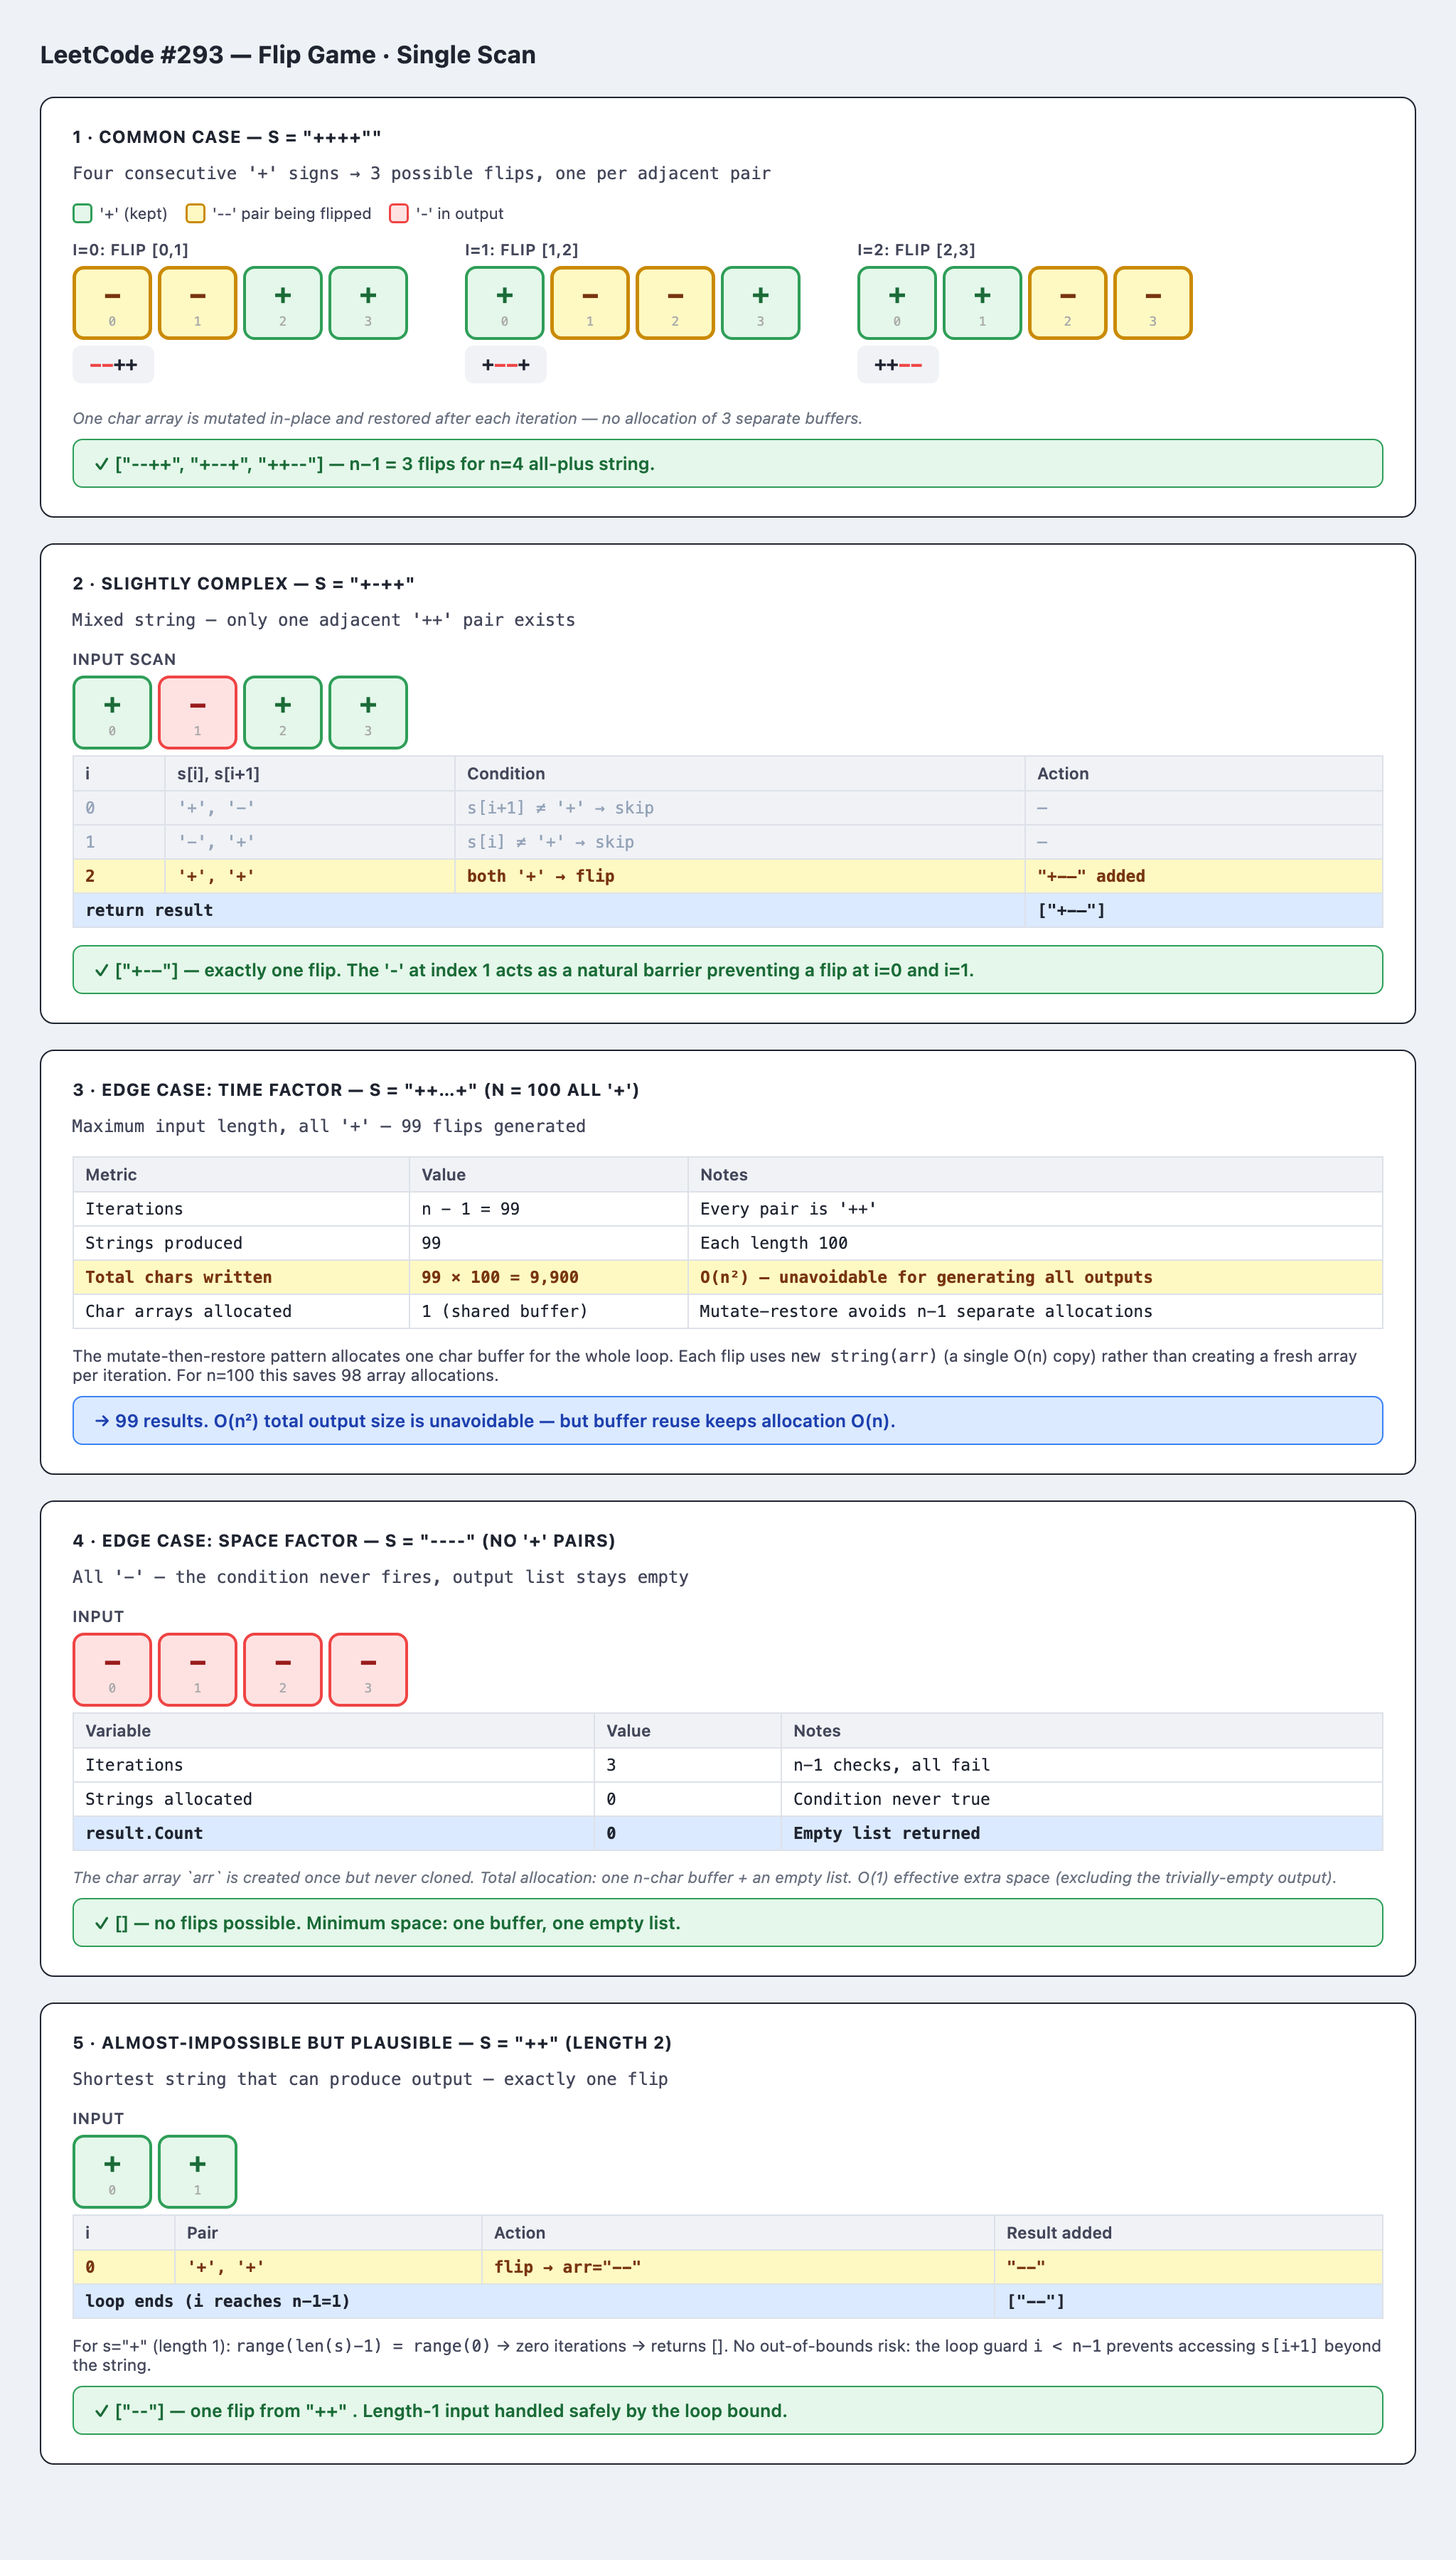